In [1]:
import collections
import os
import sys

import imblearn
import seaborn as sns
import keras_tuner
import numpy as np
import sklearn
import tensorflow as tf
import matplotlib.pyplot as plt
sys.path.append(os.path.dirname(os.path.dirname(os.path.abspath("Modules"))))
import Modules.ds_loader as ds_loader

dataset_loader_external = ds_loader.DatasetLoader(xlsx_path="../Data/Label_Map_Ext.xlsx",data_dir="../Data/External_Dataset")
X_test_external, y_test_external = dataset_loader_external.load_data()
dataset_loader = ds_loader.DatasetLoader(
    xlsx_path="../Data/Label_Map.xlsx", data_dir="../Data/Internal_Dataset"
)
X, y = dataset_loader.load_data()
X_train, X_temp, y_train, y_temp = sklearn.model_selection.train_test_split(
    X, y, test_size=0.3, random_state=42, shuffle=True
)

X_val, X_test, y_val, y_test = sklearn.model_selection.train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, shuffle=True
)
print("Unique classes in y:", np.unique(y_train))
print("Datatype:", (X_train.dtype), (y_train.dtype))
print(f"NaNs in X: {np.isnan(X_train).sum()}")
print(f"Infs in X: {np.isinf(X_train).sum()}")
print(f"Class distribution of training before SMOTE: {collections.Counter(y_train)}")
print(f"Class distribution of validation: {collections.Counter(y_val)}")
print(f"Class distribution of test: {collections.Counter(y_test)}")
print("\n[ ii ] Applying MinMax scaling to the dataset...")

print(
    f"Before scaling - X_train shape: {X_train.shape}, X_val shape: {X_val.shape}, X_test shape: {X_test.shape}, X_test_external shape: {X_test_external.shape}")

def min_max_normalize(*datasets):
    normalized_datasets = []
    for data in datasets:
        norm_data = []
        for sample in data:
            min_val = np.min(sample)
            max_val = np.max(sample)
            if max_val - min_val == 0:
                norm_sample = np.zeros_like(sample, dtype=np.float32)
            else:
                norm_sample = (sample - min_val) / (max_val - min_val)
            norm_data.append(norm_sample)
        normalized_datasets.append(np.stack(norm_data, axis=0).astype(np.float32))
    return normalized_datasets

X_train, X_val, X_test, X_test_external = min_max_normalize(X_train, X_val, X_test, X_test_external)

print(f"Min and Max of X_train: {np.min(X_train)}, {np.max(X_train)}")
print(f"Min and Max of X_val: {np.min(X_val)}, {np.max(X_val)}")
print(f"Min and Max of X_test: {np.min(X_test)}, {np.max(X_test)}")
print(f"Min and Max of X_test_external: {np.min(X_test_external)}, {np.max(X_test_external)}")

print(f"\n\n[ ii ] Applying oversampling via SMOTE")
X_train_flat = X_train.reshape((X_train.shape[0], -1))
smote = imblearn.over_sampling.SMOTE(random_state=42)
X_resampled, y_train = smote.fit_resample(X_train_flat, y_train)
X_train = X_resampled.reshape((-1, *X_train.shape[1:]))
print(f"Class distribution after SMOTE: {collections.Counter(y_train)}")

2025-05-21 13:00:46.014487: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-05-21 13:00:46.044791: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1747825246.078837   11034 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1747825246.089805   11034 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1747825246.118429   11034 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

Unique classes in y: [0 1 2 3]
Datatype: float32 int32
NaNs in X: 0
Infs in X: 0
Class distribution of training before SMOTE: Counter({np.int32(2): 2738, np.int32(1): 1594, np.int32(0): 1523, np.int32(3): 1278})
Class distribution of validation: Counter({np.int32(2): 572, np.int32(1): 346, np.int32(0): 331, np.int32(3): 280})
Class distribution of test: Counter({np.int32(2): 578, np.int32(0): 364, np.int32(1): 320, np.int32(3): 267})

[ ii ] Applying MinMax scaling to the dataset...
Before scaling - X_train shape: (7133, 500, 12), X_val shape: (1529, 500, 12), X_test shape: (1529, 500, 12), X_test_external shape: (10834, 500, 12)
Min and Max of X_train: 0.0, 1.0
Min and Max of X_val: 0.0, 1.0
Min and Max of X_test: 0.0, 1.0
Min and Max of X_test_external: 0.0, 1.0


[ ii ] Applying oversampling via SMOTE
Class distribution after SMOTE: Counter({np.int32(1): 2738, np.int32(3): 2738, np.int32(2): 2738, np.int32(0): 2738})


In [2]:
INPUT_SIZE, LAYERS = 500, 3
RDIR = f"../src/Results/RES_{INPUT_SIZE}_64_NS_01"
MDIR = f"../RES_{INPUT_SIZE}_{LAYERS}.keras"
CDIR = f"../C_RES_{INPUT_SIZE}_{LAYERS}.keras"
CVDIR = f"../RES_{INPUT_SIZE}_CV.keras"

from baseline import ResnetTuner

tuner = keras_tuner.BayesianOptimization(
    ResnetTuner(),
    objective="val_accuracy",
    max_trials=1,
    overwrite=False,
    directory=RDIR,
    project_name=f"RES_{INPUT_SIZE}_64",
)


tuner.reload()

best_trials = tuner.oracle.get_best_trials(num_trials=5)

for trial in best_trials:
    print(f"Trial ID: {trial.trial_id}, Score: {trial.score}")
    print("Hyperparameters:", trial.hyperparameters.values)

Reloading Tuner from ../src/Results/RES_500_64_NS_01/RES_500_64/tuner0.json
Trial ID: 27, Score: 0.9620667099952698
Hyperparameters: {'f_units': 64, 'dense_units_1': 32, 'dropout_1': 0.4, 'dense_units_2': 128, 'dropout_2': 0.35, 'learning_rate': 0.000979022276213945, 'weight_decay': 0.0022847198897071354, 'batch_size': 32}
Trial ID: 24, Score: 0.9601046442985535
Hyperparameters: {'f_units': 64, 'dense_units_1': 32, 'dropout_1': 0.45, 'dense_units_2': 128, 'dropout_2': 0.35, 'learning_rate': 0.0006707580587047655, 'weight_decay': 0.0006666882584119767, 'batch_size': 32}
Trial ID: 28, Score: 0.9587966203689575
Hyperparameters: {'f_units': 64, 'dense_units_1': 32, 'dropout_1': 0.45, 'dense_units_2': 128, 'dropout_2': 0.35, 'learning_rate': 0.001, 'weight_decay': 0.002495524841847735, 'batch_size': 32}
Trial ID: 25, Score: 0.9574885368347168
Hyperparameters: {'f_units': 64, 'dense_units_1': 32, 'dropout_1': 0.45, 'dense_units_2': 128, 'dropout_2': 0.35, 'learning_rate': 0.001, 'weight_deca

I0000 00:00:1747825316.735332   11034 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 4146 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


In [3]:
model = tuner.get_best_models(num_models=1)[0]

/home/capitan/.venv/tenv/lib64/python3.11/site-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 118 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [4]:
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print(f"Test Loss: {test_loss}")
print(f"Test Accuracy: {test_accuracy}")
test_loss, test_accuracy = model.evaluate(X_test_external, y_test_external)
print(f"External Test Loss: {test_loss}")
print(f"External Test Accuracy: {test_accuracy}")

I0000 00:00:1747825319.019779   11445 service.cc:152] XLA service 0x7fa3280283c0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1747825319.019800   11445 service.cc:160]   StreamExecutor device (0): NVIDIA GeForce RTX 4050 Laptop GPU, Compute Capability 8.9
2025-05-21 13:01:59.043936: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1747825319.178242   11445 cuda_dnn.cc:529] Loaded cuDNN version 90300
2025-05-21 13:01:59.594369: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_439', 4 bytes spill stores, 4 bytes spill loads



24/48 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9647 - loss: 0.1541 

I0000 00:00:1747825320.538710   11445 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


48/48 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - accuracy: 0.9637 - loss: 0.1558
Test Loss: 0.15903717279434204
Test Accuracy: 0.9627207517623901
339/339 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.7817 - loss: 0.8976
External Test Loss: 0.6909795999526978
External Test Accuracy: 0.8104116916656494


In [5]:
y_pred = model.predict(X_test)

if y_pred.shape[1] == 1:  
    y_pred_binary = (y_pred > 0.5).astype(int)
    auc = sklearn.metrics.roc_auc_score(y_test, y_pred)  
else:
    y_pred_binary = np.argmax(y_pred, axis=1)  
    auc = sklearn.metrics.roc_auc_score(y_test, y_pred, multi_class='ovr')

print("Classification Report (Test Data):")
print(sklearn.metrics.classification_report(y_test, y_pred_binary))
print(f"AUC: {auc}")

y_test_external_pred = model.predict(X_test_external)
y_test_external_pred = np.argmax(y_test_external_pred, axis=1)

print("\nClassification Report (Test External Data):")
print(sklearn.metrics.classification_report(y_test_external, y_test_external_pred))


48/48 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step
Classification Report (Test Data):
              precision    recall  f1-score   support

           0       0.96      0.94      0.95       364
           1       0.91      0.95      0.93       320
           2       1.00      0.99      0.99       578
           3       0.97      0.96      0.96       267

    accuracy                           0.96      1529
   macro avg       0.96      0.96      0.96      1529
weighted avg       0.96      0.96      0.96      1529

AUC: 0.9916116413723208
339/339 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step

Classification Report (Test External Data):
              precision    recall  f1-score   support

           0       0.91      0.81      0.86      1008
           1       0.25      0.99      0.40       229
           2       0.26      0.99      0.41       456
           3       1.00      0.80      0.89      9141

    accuracy                           0.81     10834
   macro avg       0.61      0.89      0.64     10834


In [6]:
best_trial = tuner.oracle.get_best_trials(num_trials=1)[0]
best_hps = best_trial.hyperparameters.values

# Print all best hyperparameters
print("Best Hyperparameters:")
for key, value in best_hps.items():
    print(f"{key}: {value}")


Best Hyperparameters:
f_units: 64
dense_units_1: 32
dropout_1: 0.4
dense_units_2: 128
dropout_2: 0.35
learning_rate: 0.000979022276213945
weight_decay: 0.0022847198897071354
batch_size: 32


In [7]:
from baseline import Resnet
model_builder = Resnet()

In [9]:
kfold = sklearn.model_selection.KFold(n_splits=5, shuffle=True, random_state=42)
fold_accuracies = []
fold_histories = []

best_accuracy = 0.0
best_model = None  

for fold, (train_idx, val_idx) in enumerate(kfold.split(X_train, y_train)):
    print(f"\n--- Fold {fold+1} ---")

    X_tr, X_val_fold = X_train[train_idx], X_train[val_idx]
    y_tr, y_val_fold = y_train[train_idx], y_train[val_idx]

    model = model_builder.build_model(
        #m_convolutions=best_hps.get("m_convolutions"),
        #n_convolutions=best_hps.get("n_convolutions"),
        c_units=best_hps.get("f_units"),
        #p_size=best_hps.get("p_size"),
        d_units_1=best_hps.get("dense_units_1"),
        dropout_1=best_hps.get("dropout_1"),
        #dropout_1 = 0.5,
        d_units_2=best_hps.get("dense_units_2"),
        dropout_2=best_hps.get("dropout_2"),
        #dropout_2 = 0.35,
        learning_rate=best_hps.get("learning_rate"),
        #learning_rate=9e-4,
        weight_decay=best_hps.get("weight_decay"),
    )

    lr_scheduler = tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss", factor=0.5, patience=4, min_lr=1e-8, verbose=1
    )

    early_stopping = tf.keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=10, restore_best_weights=True, verbose=1
    )

    model_checkpoint = tf.keras.callbacks.ModelCheckpoint(
        filepath=CDIR, monitor="val_accuracy", save_best_only=True, verbose=1
    )

    history = model.fit(
        X_tr, y_tr,
        validation_data=(X_val_fold, y_val_fold),
        epochs=300,
        callbacks=[lr_scheduler, early_stopping, model_checkpoint],
        verbose=1
    )

    val_loss, val_accuracy = model.evaluate(X_val_fold, y_val_fold, verbose=0)
    print(f"Fold {fold+1} Validation Accuracy: {val_accuracy:.4f}")
    fold_accuracies.append(val_accuracy)
    fold_histories.append(history)

    if val_accuracy > best_accuracy:
        best_accuracy = val_accuracy
        best_model = model
        model.save(CVDIR) 
        print(f"Saved best model from Fold {fold+1} with Accuracy: {val_accuracy:.4f}")

print("Cross-validation accuracies:", fold_accuracies)
print("Average CV accuracy:", np.mean(fold_accuracies))
print("Max CV accuracy:", np.max(fold_accuracies))
cv_model = tf.keras.models.load_model(CVDIR)


--- Fold 1 ---
Epoch 1/300
274/274 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.3136 - loss: 1.3731

2025-05-21 13:04:04.956008: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_347', 12 bytes spill stores, 12 bytes spill loads




Epoch 1: val_accuracy improved from -inf to 0.49703, saving model to ../C_RES_500_3.keras
274/274 ━━━━━━━━━━━━━━━━━━━━ 22s 36ms/step - accuracy: 0.3139 - loss: 1.3726 - val_accuracy: 0.4970 - val_loss: 1.1055 - learning_rate: 9.7902e-04
Epoch 2/300
271/274 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6175 - loss: 0.8437
Epoch 2: val_accuracy improved from 0.49703 to 0.76997, saving model to ../C_RES_500_3.keras
274/274 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.6177 - loss: 0.8431 - val_accuracy: 0.7700 - val_loss: 0.5429 - learning_rate: 9.7902e-04
Epoch 3/300
269/274 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7359 - loss: 0.6404
Epoch 3: val_accuracy did not improve from 0.76997
274/274 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.7361 - loss: 0.6402 - val_accuracy: 0.6308 - val_loss: 0.8527 - learning_rate: 9.7902e-04
Epoch 4/300
268/274 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7760 - loss: 0.5620
Epoch 4: val_accuracy did not improve from 0.76997
274/274 ━━━━━━━━

2025-05-21 13:08:13.184519: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_347', 12 bytes spill stores, 12 bytes spill loads




Epoch 1: val_accuracy improved from -inf to 0.54064, saving model to ../C_RES_500_3.keras
274/274 ━━━━━━━━━━━━━━━━━━━━ 16s 29ms/step - accuracy: 0.3003 - loss: 1.3555 - val_accuracy: 0.5406 - val_loss: 1.0776 - learning_rate: 9.7902e-04
Epoch 2/300
268/274 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5714 - loss: 0.9800
Epoch 2: val_accuracy improved from 0.54064 to 0.75251, saving model to ../C_RES_500_3.keras
274/274 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.5716 - loss: 0.9796 - val_accuracy: 0.7525 - val_loss: 0.6680 - learning_rate: 9.7902e-04
Epoch 3/300
274/274 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5966 - loss: 0.9099
Epoch 3: val_accuracy improved from 0.75251 to 0.75434, saving model to ../C_RES_500_3.keras
274/274 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.5967 - loss: 0.9098 - val_accuracy: 0.7543 - val_loss: 0.6929 - learning_rate: 9.7902e-04
Epoch 4/300
274/274 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6422 - loss: 0.8599
Epoch 4: val_accuracy imp

In [10]:
def evaluate_model(model, X, y, label="Test"):
    print(f"\n[== Evaluation on {label} Data ==]")

    loss, accuracy = model.evaluate(X, y, batch_size=32, verbose=0)
    print(f"{label} Loss: {loss:.4f}")
    print(f"{label} Accuracy: {accuracy:.4f}")

    y_pred_probs = model.predict(X, verbose=0)
    y_pred = np.argmax(y_pred_probs, axis=1)

    print(f"\nClassification Report ({label} Data):")
    print(sklearn.metrics.classification_report(y, y_pred))

    try:
        auc = sklearn.metrics.roc_auc_score(y, y_pred_probs, multi_class='ovr')
        print(f"{label} AUC: {auc:.4f}")
    except Exception as e:
        print(f"AUC could not be calculated: {e}")

    plot_confusion_matrix(y, y_pred, label)


def plot_confusion_matrix(y_true, y_pred, label="Test"):
    cm = sklearn.metrics.confusion_matrix(y_true, y_pred, normalize='true')
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt=".2f", cmap="Blues",
                xticklabels=np.unique(y_true),
                yticklabels=np.unique(y_true))
    plt.xlabel('Predicted Labels')
    plt.ylabel('True Labels')
    plt.title(f'Confusion Matrix ({label} Data)')
    plt.show()



[== Evaluation on Test Data ==]
Test Loss: 0.1680
Test Accuracy: 0.9601

Classification Report (Test Data):
              precision    recall  f1-score   support

           0       0.91      0.97      0.94       364
           1       0.95      0.89      0.92       320
           2       0.99      0.99      0.99       578
           3       0.97      0.96      0.97       267

    accuracy                           0.96      1529
   macro avg       0.96      0.95      0.95      1529
weighted avg       0.96      0.96      0.96      1529

Test AUC: 0.9932


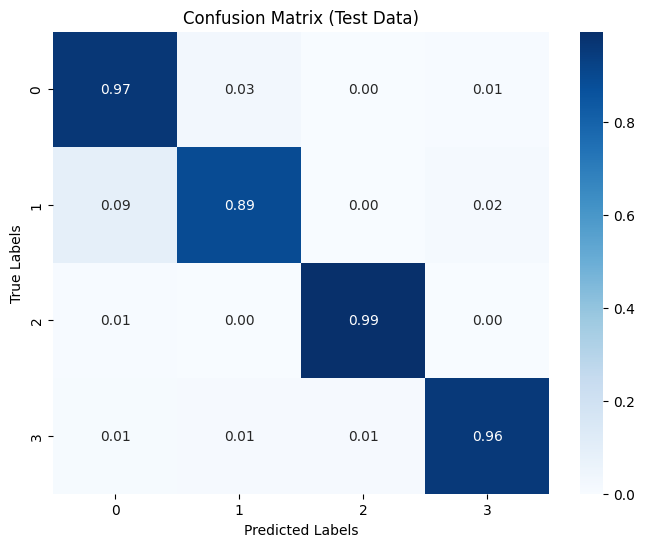

In [11]:
evaluate_model(cv_model, X_test, y_test, label="Test")


[== Evaluation on External Test Data ==]
External Test Loss: 1.5760
External Test Accuracy: 0.7808

Classification Report (External Test Data):
              precision    recall  f1-score   support

           0       0.65      0.86      0.74      1008
           1       0.33      0.85      0.47       229
           2       0.23      0.99      0.38       456
           3       1.00      0.76      0.86      9141

    accuracy                           0.78     10834
   macro avg       0.55      0.87      0.61     10834
weighted avg       0.92      0.78      0.82     10834

External Test AUC: 0.9544


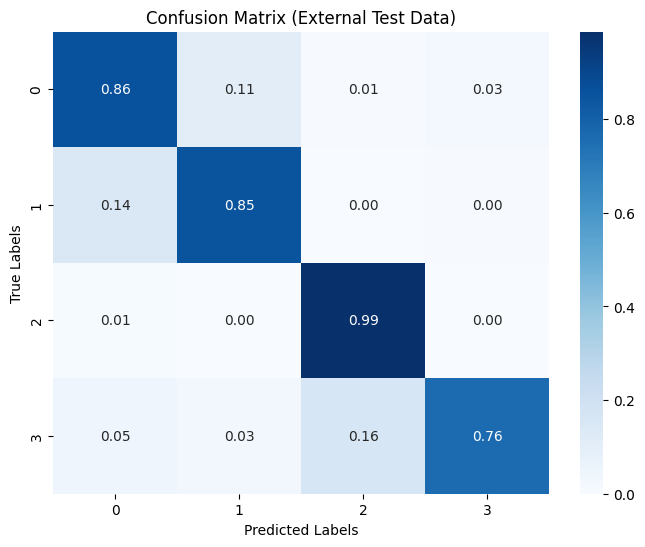

In [12]:
evaluate_model(cv_model, X_test_external, y_test_external, label="External Test")

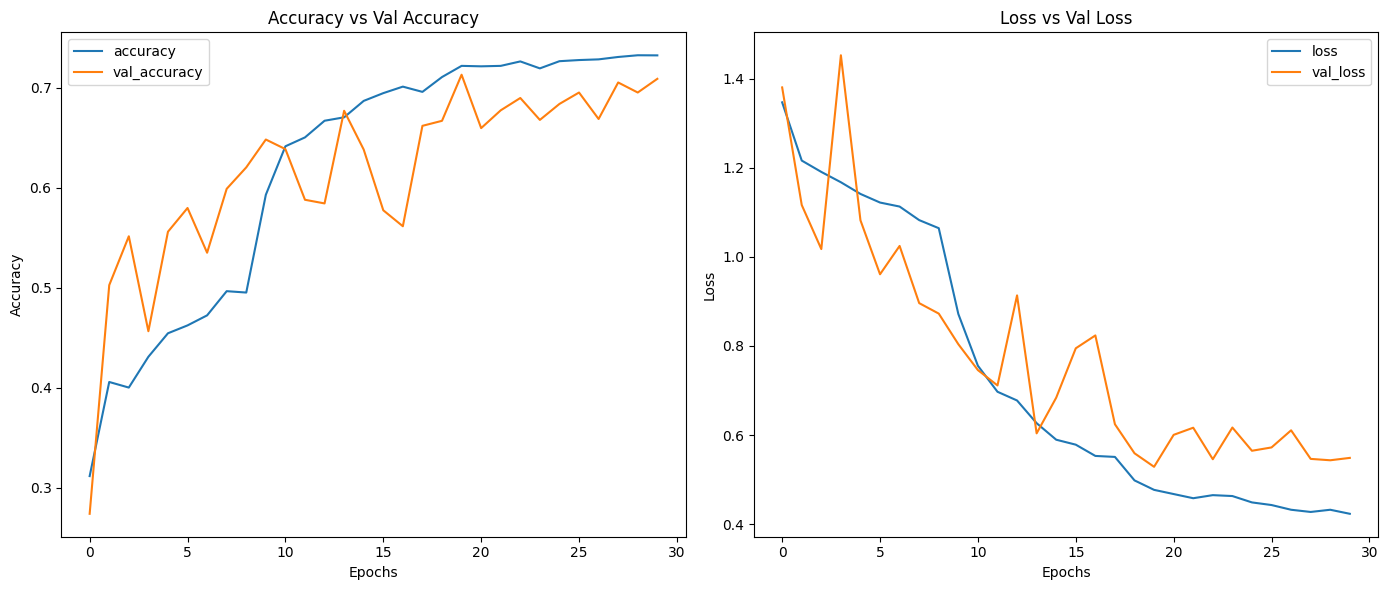

In [13]:
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

ax[0].plot(history.history['accuracy'], label='accuracy')
ax[0].plot(history.history['val_accuracy'], label='val_accuracy')
ax[0].set_title('Accuracy vs Val Accuracy')
ax[0].set_xlabel('Epochs')
ax[0].set_ylabel('Accuracy')
ax[0].legend()

ax[1].plot(history.history['loss'], label='loss')
ax[1].plot(history.history['val_loss'], label='val_loss')
ax[1].set_title('Loss vs Val Loss')
ax[1].set_xlabel('Epochs')
ax[1].set_ylabel('Loss')
ax[1].legend()

plt.tight_layout()
plt.show()